In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from math import sqrt

import sys
sys.path.append("../../scripts")

from model import Model, model_from_file
from model_plot import model_plot
from norms import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
data_dir = 'data_leap/'

$$f(\phi) = 4 \phi^3 - 3 \phi^4$$
$$g(\phi) = 1 - \cfrac{\delta (1 + \delta)}{\delta + 4 \phi^3 - 3 \phi^4} + \delta$$
$$\epsilon(\phi) = \epsilon_0 + \cfrac{\epsilon_0}{\delta} [1 - g(\phi)] = \epsilon_0 + \epsilon_0 \cdot \left( \cfrac{1 + \delta}{\delta + 4 \phi^3 - 3 \phi^4} - 1 \right)$$

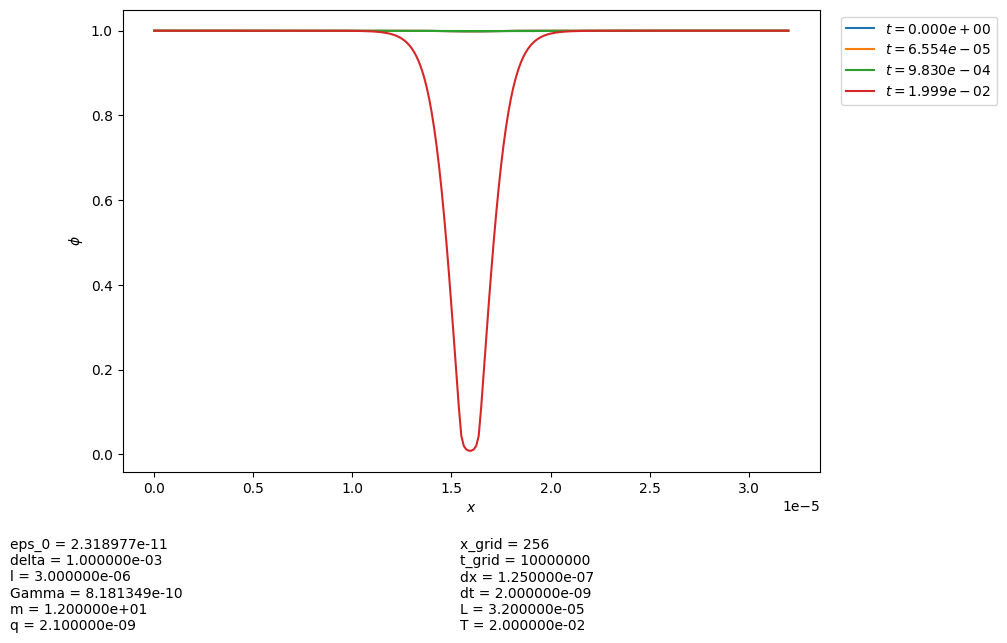

In [4]:
model = model_from_file(data_dir + 'model.csv')
params = model.params
model_plot(model, [0, 5e-5, 1e-3, 2e-2], figsize=(9, 6))

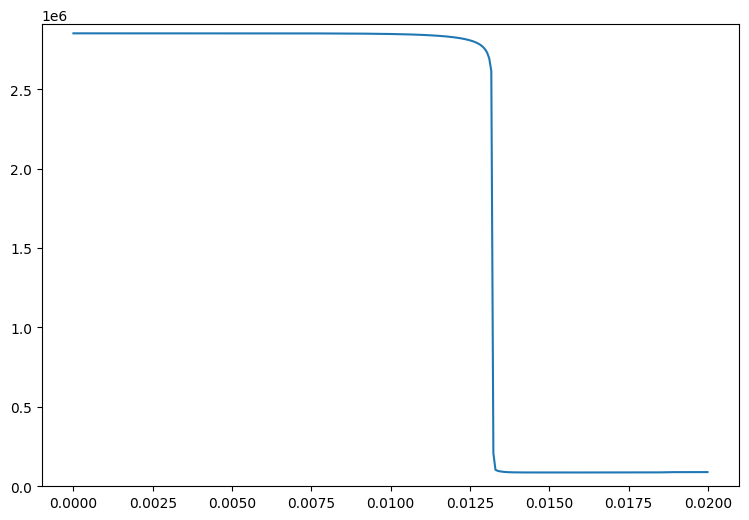

In [5]:
plt.figure(figsize=(9, 6))
plt.ylim([0, model.E[0] * 1.02])
plt.plot(model.ts, model.E)
plt.show()

In [6]:
model.E[0] / model.E[-1]

np.float64(31.95803299817603)

Канал вполне близок к развитому:

In [7]:
E_natural = 1.0 / model.params['l'] * sqrt(
    2.0 * params['Gamma'] * params['delta'] / params['eps_0']
)
print('{:e} {:e}'.format(model.E[0], model.E[-1]))
print('{:e}'.format(E_natural))

2.852017e+06 8.924256e+04
8.854377e+04


In [8]:
chi = params['q']**2 * params['l']**2 / (
    2.0 * params['Gamma'] * params['delta'] * params['eps_0'] * params['L']**2
) * (-12.0 * params['delta'] * (1.0 + params['delta'])) / (-12.0)
chi

1.0225014430189685

In [9]:
model.phi[-1].min()

np.float64(0.00841824208)

Приближение $\epsilon$ "ступенькой" работает неплохо:

In [10]:
eps_int = (params['eps_0'] / (
    params['delta'] + 4.0 * model.phi[-1]**3 - 3.0 * model.phi[-1]**4
)).sum() * params['dx']
print('{:e}'.format(eps_int))

2.369442e-14


In [11]:
eps_int_approx = params['L'] * params['eps_0'] + params['l'] * params['eps_0'] / params['delta']
print('{:e}\n{:e} {:e}'.format(
    eps_int_approx,
    params['L'] * params['eps_0'],
    params['l'] * params['eps_0'] / params['delta']
))

7.031137e-14
7.420725e-16 6.956930e-14


In [12]:
E_breakdown = params['delta'] / params['l'] * (
    params['L'] / (params['L'] * params['delta'] + params['l'])
) * sqrt(
    2.0 * params['Gamma'] / params['eps_0']
)
print('{:e}'.format(E_breakdown))

2.955145e+04


Теоретические результаты в целом подтверждаются.

Для $E_N \overset{C}{\sim} E_B$ нужно $f'' / g'' \overset{C}{\sim} \delta^{-2}$, а в сейчас в модели только $f'' / g'' \overset{C}{\sim} \delta^{-1}$. Однако профиль канала имеет визуальный предел при $\delta \to +0$ !

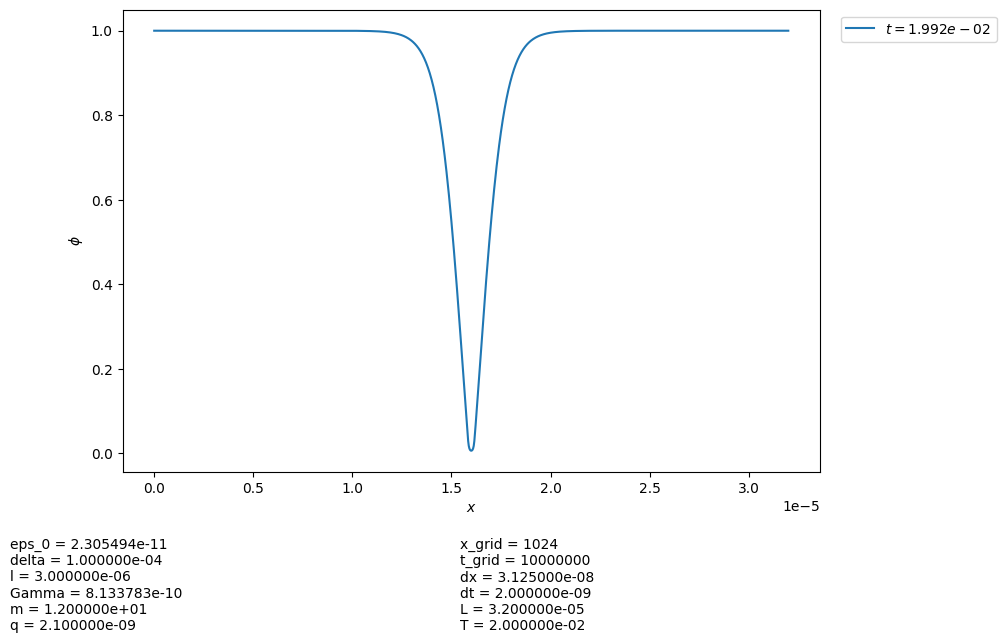

In [13]:
model_m4 = model_from_file(data_dir + 'model_m4.csv')
model_plot(model_m4, [2e-2], figsize=(9, 6))

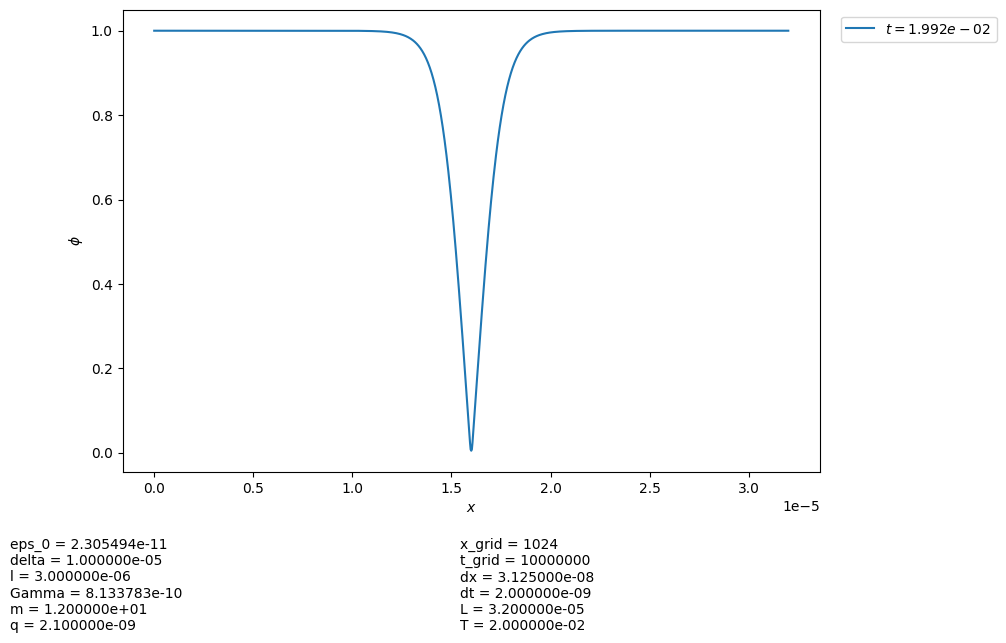

In [14]:
model_m5 = model_from_file(data_dir + 'model_m5.csv')
model_plot(model_m5, [2e-2], figsize=(9, 6))

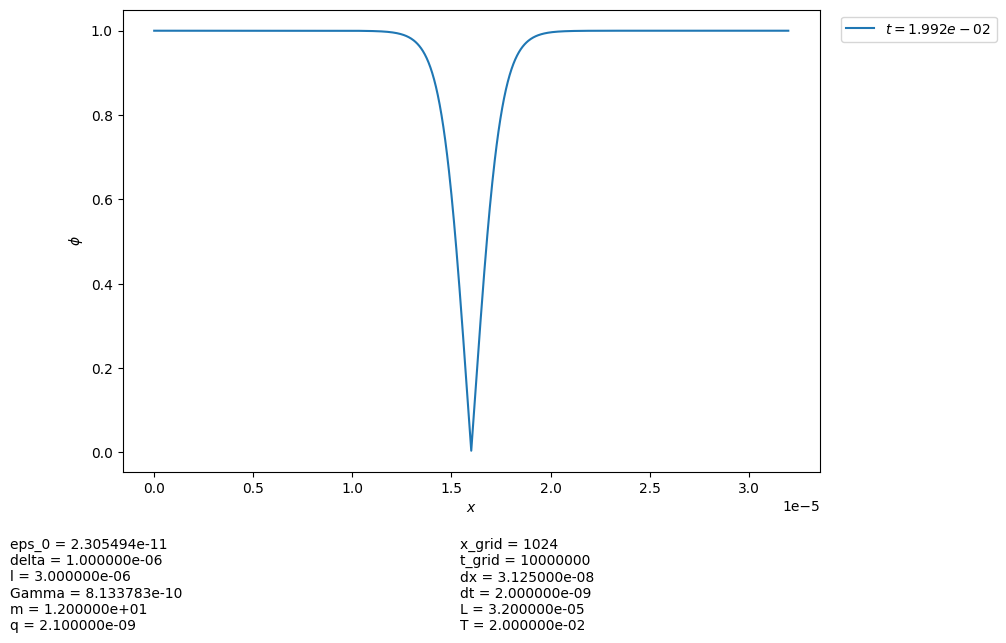

In [15]:
model_m6 = model_from_file(data_dir + 'model_m6.csv')
model_plot(model_m6, [2e-2], figsize=(9, 6))

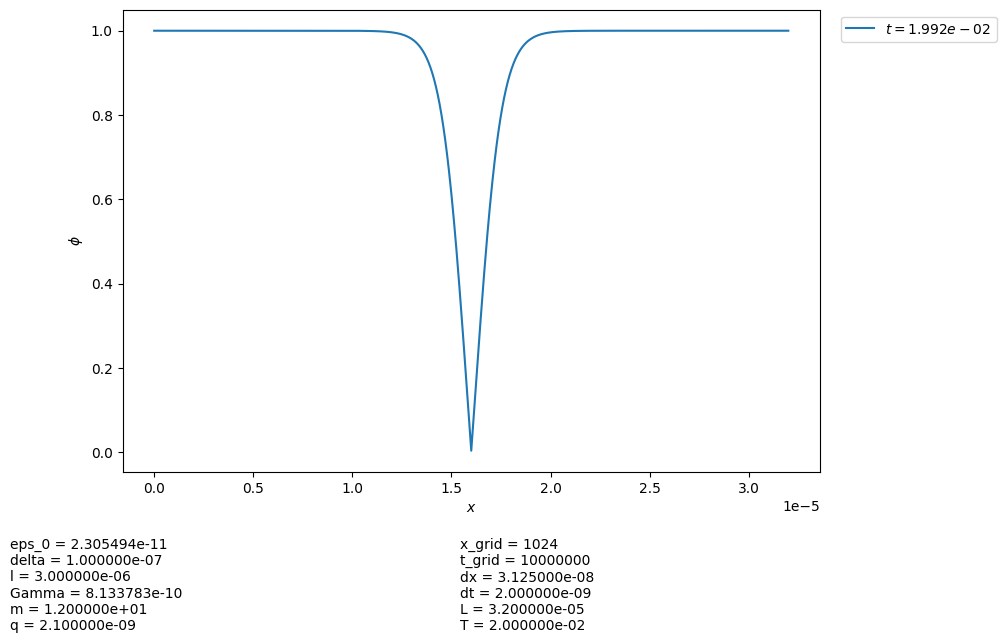

In [16]:
model_m7 = model_from_file(data_dir + 'model_m7.csv')
model_plot(model_m7, [2e-2], figsize=(9, 6))

In [17]:
models = [model, model_m4, model_m5, model_m6, model_m7]

In [18]:
for model in models:
    print('{:e}'.format(model.E[-1]))

8.924256e+04
2.811970e+04
9.514215e+03
3.455937e+03
9.646953e+02


Происходит убывание $E = \mathcal{O}(\sqrt{\delta})$, тогда как для развитого канала $E_B = \mathcal{O}(\delta)$.